# 02 Error Analysis: NWP予報誤差の特性分析

**目的**: 4 つの補正ターゲット（気温・降水・雲量・下層雲量）の誤差特性を詳細に分析し、
特徴量グループの設計根拠を定量的に示す。

**特徴量グループの構成**:
- **A群（生の予報値）**: `forecast_temperature_2m`, `forecast_precipitation`, `forecast_pressure_msl` など。
  加工なしでそのままモデルに投入する。分析は `01_eda.ipynb` で実施済み。
- **B〜F群（エンジニアリング特徴量）**: 以下の仮説に基づいて設計する。

**仮説**:
1. 誤差に時間帯・季節パターンがある → **時間コンテキスト特徴量（B群）**
2. 直前の誤差が将来の誤差を予測できる → **誤差ラグ・ローリング特徴量（C群）**
3. 予報値の急変が誤差と相関する → **予報ブレ特徴量（D群）**
4. 気圧傾向・露点差などの大気パターンが誤差と相関する → **大気パターン特徴量（E群）**
5. 実測の直近観測が有効 → **実値ラグ特徴量（F群）**

## Setup

In [1]:
import sys
from pathlib import Path

_nb_dir = next(p for p in [Path("."), Path("notebooks")] if (p / "utils.py").exists())
sys.path.insert(0, str(_nb_dir.resolve()))

from utils import ERROR_COLS, ERROR_UNITS, load_base_dataset  # noqa: E402

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)
UNITS = ERROR_UNITS  # 既存セルの UNITS 参照を維持するためのエイリアス

## データロード & 誤差計算

In [2]:
merged = load_base_dataset()
print(f"merged: {len(merged):,} rows")
display(merged[ERROR_COLS].describe().round(3))

merged: 26,304 rows


,temp_error,precip_error,cloud_error,cloud_low_error
count,26304.000,26304.000,26304.000,26304.000
mean,0.319,0.007,20.028,4.496
std,1.293,0.762,30.742,28.387
min,-6.900,-30.300,-100.000,-100.000
25%,-0.500,0.000,0.000,-4.000
50%,0.200,0.000,14.000,0.000
75%,1.100,0.000,41.000,8.000
max,7.500,20.100,100.000,100.000


## 誤差の分布

正規分布に近いか、裾が重いか、非対称か（系統バイアス）を確認する。

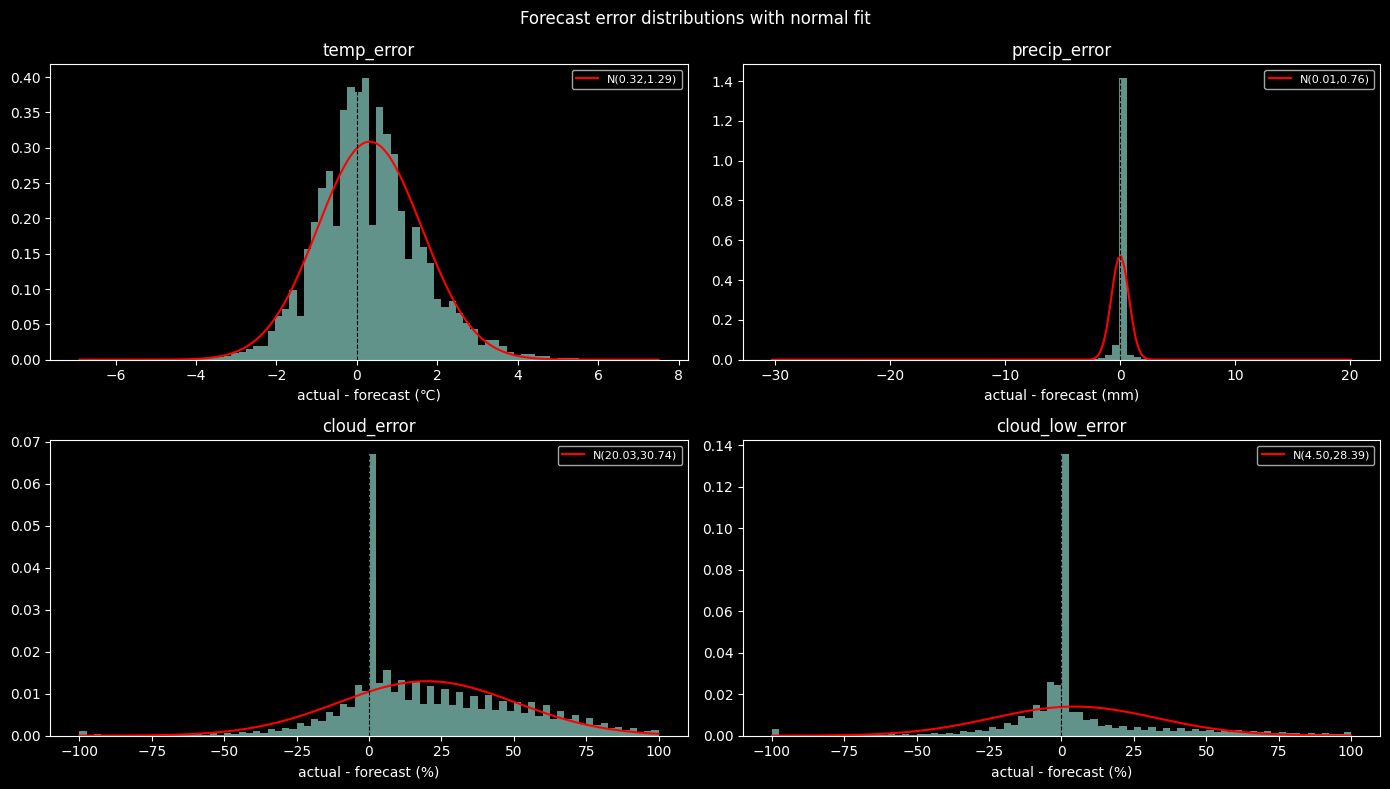

temp_error            skew=0.341  kurt=1.283
precip_error          skew=-4.759  kurt=273.363
cloud_error           skew=0.076  kurt=0.631
cloud_low_error       skew=0.350  kurt=3.294


In [3]:
UNITS = {"temp_error": "℃", "precip_error": "mm", "cloud_error": "%", "cloud_low_error": "%"}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flat, ERROR_COLS):
    s = merged[col].dropna()
    ax.hist(s, bins=80, density=True, alpha=0.7, edgecolor="none")
    # 正規分布フィット
    mu, sigma = s.mean(), s.std()
    x = np.linspace(s.min(), s.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), "r-", lw=1.5, label=f"N({mu:.2f},{sigma:.2f})")
    ax.axvline(0, color="black", lw=0.8, linestyle="--")
    ax.set_title(col)
    ax.set_xlabel(f"actual - forecast ({UNITS[col]})")
    ax.legend(fontsize=8)

plt.suptitle("Forecast error distributions with normal fit")
plt.tight_layout()
plt.show()

# 歪度・尖度
for col in ERROR_COLS:
    s = merged[col].dropna()
    print(f"{col:20s}  skew={s.skew():.3f}  kurt={s.kurtosis():.3f}")

## 仮説①: 時間帯・季節パターン → 時間コンテキスト特徴量（B群）

NWP は短周期（1時間）で出力されるが、大気の実際の変化にはラグがある。
特に気温誤差には日変化サイクルが乗る可能性が高い。

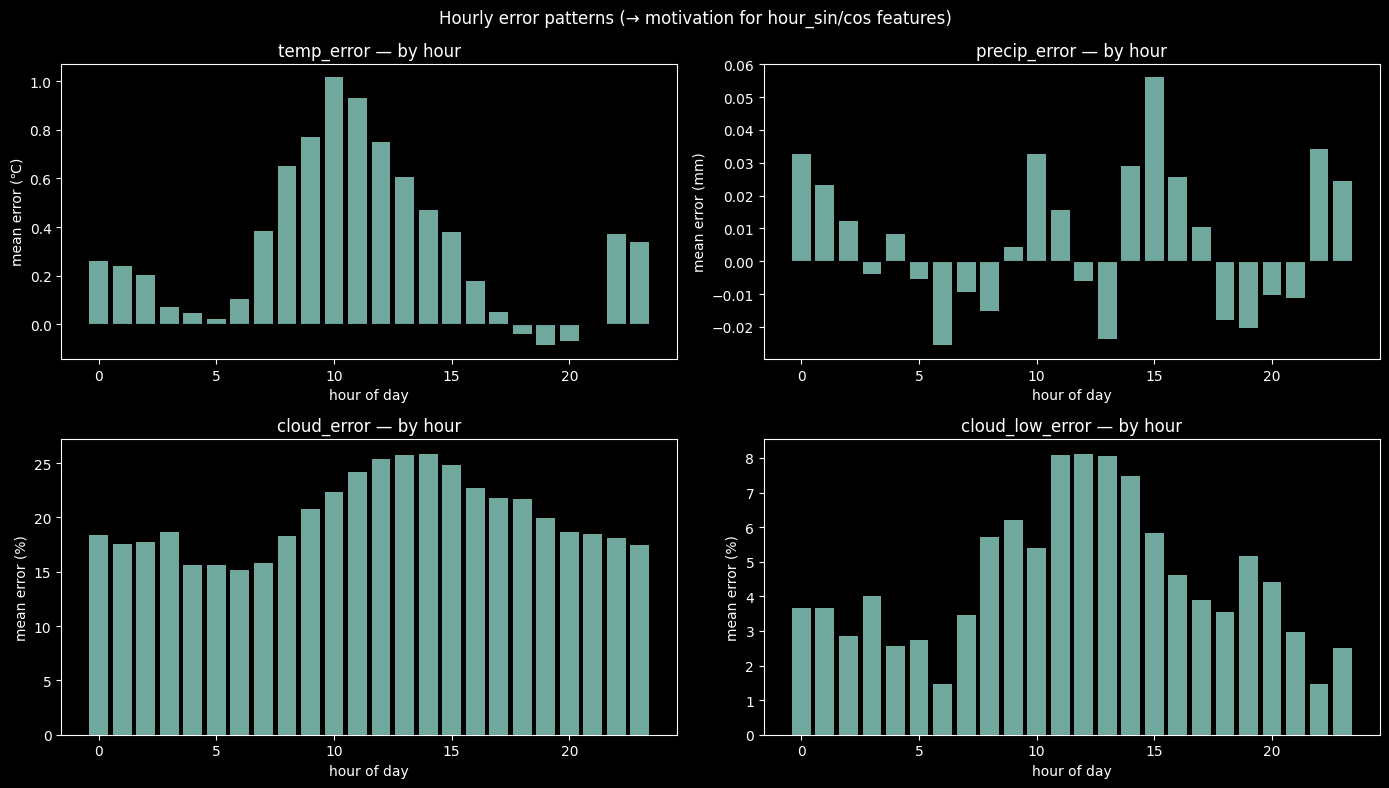

In [4]:
merged["hour"]  = merged["datetime"].dt.hour
merged["month"] = merged["datetime"].dt.month

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flat, ERROR_COLS):
    hourly = merged.groupby("hour")[col].mean()
    ax.bar(hourly.index, hourly.values, alpha=0.8)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("hour of day")
    ax.set_ylabel(f"mean error ({UNITS[col]})")
    ax.set_title(f"{col} — by hour")

plt.suptitle("Hourly error patterns (→ motivation for hour_sin/cos features)")
plt.tight_layout()
plt.show()

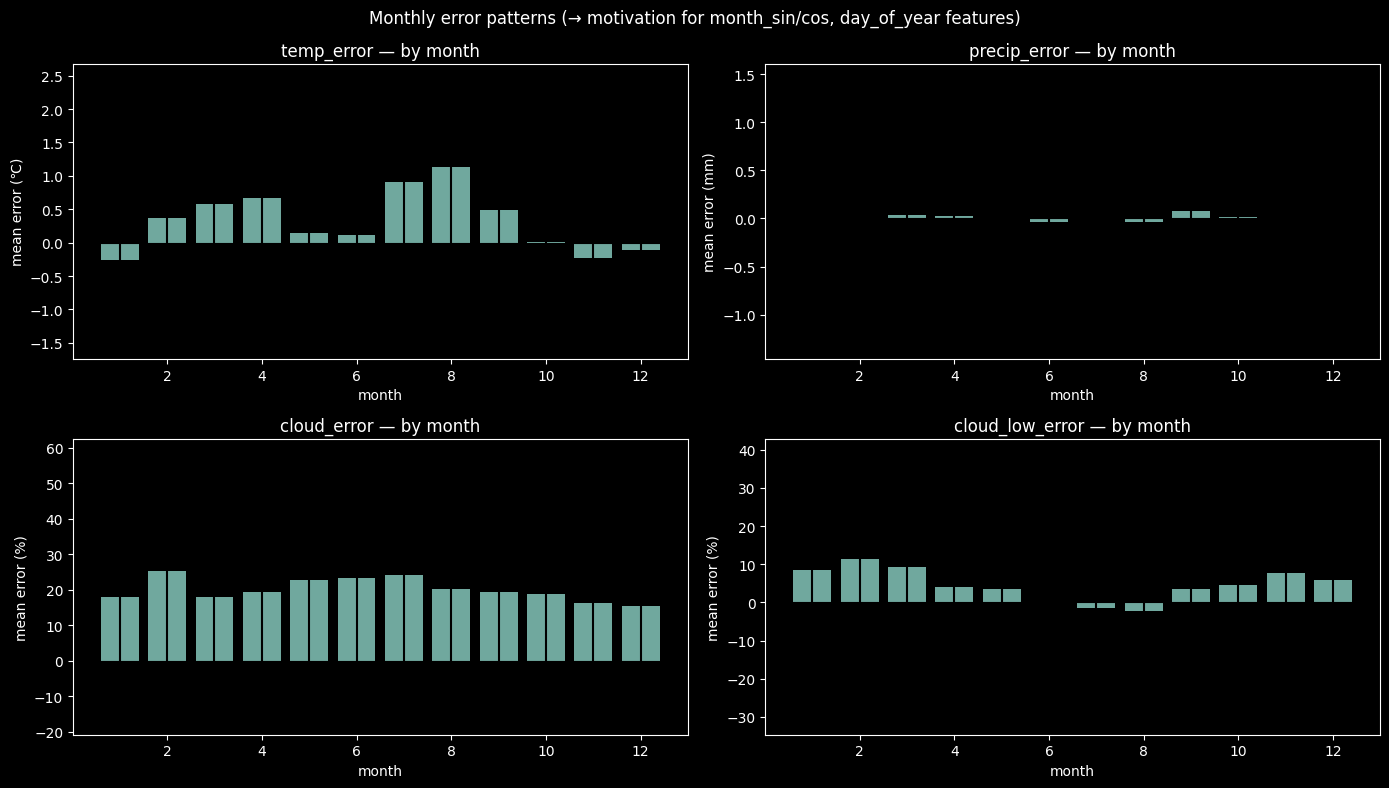

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flat, ERROR_COLS):
    monthly = merged.groupby("month")[col].agg(["mean", "std"])
    ax.bar(monthly.index, monthly["mean"], alpha=0.8)
    ax.errorbar(monthly.index, monthly["mean"], yerr=monthly["std"], fmt="none", color="black", capsize=3)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("month")
    ax.set_ylabel(f"mean error ({UNITS[col]})")
    ax.set_title(f"{col} — by month")

plt.suptitle("Monthly error patterns (→ motivation for month_sin/cos, day_of_year features)")
plt.tight_layout()
plt.show()

## 仮説②: 誤差の自己相関 → 誤差ラグ・ローリング特徴量（C群）

誤差が時系列的に相関していれば、過去の誤差から将来の誤差が予測できる。
→ `error_lag_1h`, `error_lag_6h`, `error_rolling_mean_24h` などが有効。

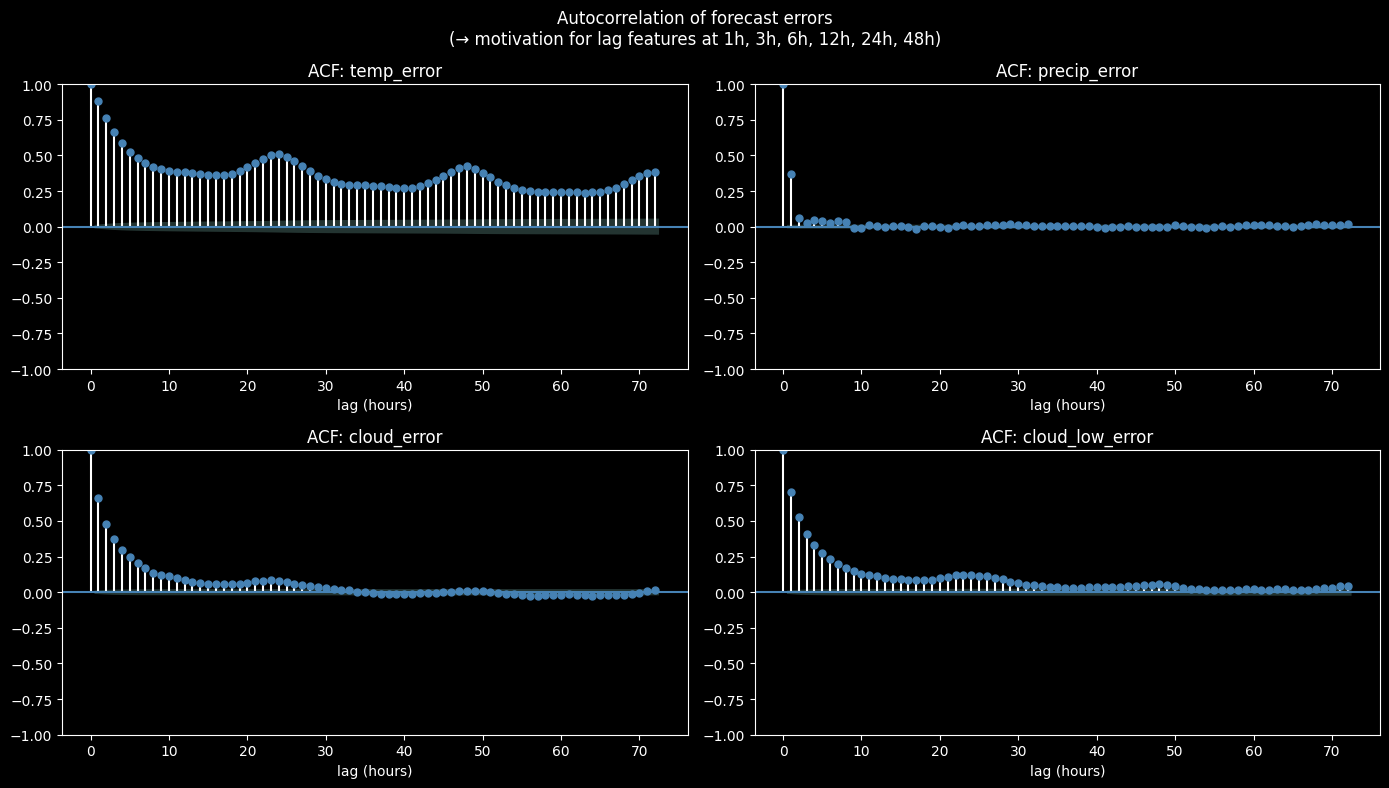

In [6]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flat, ERROR_COLS):
    s = merged[col].dropna()
    plot_acf(s, lags=72, ax=ax, alpha=0.05, color="steelblue")
    ax.set_title(f"ACF: {col}")
    ax.set_xlabel("lag (hours)")

plt.suptitle("Autocorrelation of forecast errors\n(→ motivation for lag features at 1h, 3h, 6h, 12h, 24h, 48h)")
plt.tight_layout()
plt.show()

In [7]:
# 各ラグでの自己相関係数を数値で確認
# 目的: 「誤差に自己相関がある」= C 群（誤差ラグ・ローリング）を設計する根拠を定量的に示す。
LAG_HOURS = [1, 3, 6, 12, 24, 48]

acf_table = {}
for col in ERROR_COLS:
    vals = merged[col].to_numpy(dtype=float)
    acf_table[col] = {
        lag: float(np.corrcoef(vals[lag:], vals[:-lag])[0, 1])
        for lag in LAG_HOURS
    }

# index を整数で作成してからラベルを付ける（整数キーと文字列 index の不一致を避ける）
acf_df = pd.DataFrame(acf_table, index=LAG_HOURS)
acf_df.index = [f"lag_{h}h" for h in LAG_HOURS]
display(acf_df.round(3))

,temp_error,precip_error,cloud_error,cloud_low_error
lag_1h,0.884,0.369,0.661,0.706
lag_3h,0.664,0.026,0.370,0.409
lag_6h,0.480,0.023,0.208,0.233
lag_12h,0.380,0.006,0.088,0.111
lag_24h,0.510,0.007,0.081,0.124
lag_48h,0.424,0.000,0.009,0.054


In [8]:
# rolling_mean: 単一ラグより系統バイアスを安定的に捉えるか
# 比較: rolling_mean_{w}h の相関係数 vs lag_{w}h の相関係数（shift=1 でリーク防止）
merged_sorted2 = merged.sort_values("datetime").reset_index(drop=True)

rm_rows = {}
for col in ERROR_COLS:
    s  = merged_sorted2[col]
    s1 = s.shift(1)  # 1 ステップずらして rolling（自己参照を防ぐ）
    row = {}
    for w in [6, 12, 24, 48]:
        rm  = s1.rolling(w, min_periods=max(1, w // 2)).mean()
        row[f"rolling_mean_{w}h"] = float(s.corr(rm))
        row[f"lag_{w}h"]          = float(s.corr(s.shift(w)))
    rm_rows[col] = row

rm_df = pd.DataFrame(rm_rows).T
# rolling と lag を交互に並べて比較しやすくする
ordered_cols = [c for w in [6, 12, 24, 48] for c in [f"rolling_mean_{w}h", f"lag_{w}h"]]
display(rm_df[ordered_cols].round(3))
print("→ rolling_mean は同じ窓幅の lag 単値よりも一貫して高い相関（ノイズ平滑化の効果）")

,rolling_mean_6h,lag_6h,rolling_mean_12h,lag_12h,rolling_mean_24h,lag_24h,rolling_mean_48h,lag_48h
temp_error,0.733,0.480,0.653,0.380,0.642,0.510,0.594,0.424
precip_error,0.173,0.023,0.129,0.006,0.090,0.007,0.070,0.000
cloud_error,0.502,0.208,0.394,0.088,0.311,0.081,0.212,0.009
cloud_low_error,0.535,0.233,0.426,0.111,0.353,0.124,0.278,0.054


→ rolling_mean は同じ窓幅の lag 単値よりも一貫して高い相関（ノイズ平滑化の効果）


In [9]:
# rolling_std: 直近の誤差ばらつき → 将来の誤差絶対値の予測力
std_rows = {}
for col in ERROR_COLS:
    s  = merged_sorted2[col]
    s1 = s.shift(1)
    row = {}
    for w in [6, 12, 24, 48]:
        rs = s1.rolling(w, min_periods=max(1, w // 2)).std()
        row[f"rolling_std_{w}h"] = float(s.abs().corr(rs))
    std_rows[col] = row

std_df = pd.DataFrame(std_rows).T
display(std_df.round(3))
print("→ rolling_std は |error| と正の相関。直近の誤差ばらつきが大きい時間帯は次も不確実性が高い")

,rolling_std_6h,rolling_std_12h,rolling_std_24h,rolling_std_48h
temp_error,0.205,0.181,0.173,0.148
precip_error,0.463,0.375,0.279,0.192
cloud_error,0.315,0.294,0.219,0.153
cloud_low_error,0.453,0.411,0.358,0.286


→ rolling_std は |error| と正の相関。直近の誤差ばらつきが大きい時間帯は次も不確実性が高い


**観測:**

- **lag_1h〜lag_6h**: 全ターゲットで明確な自己相関 → C 群を採用する主根拠
- **lag_12h〜lag_48h**: `temp_error` では `lag_24h=0.51`（日周期の名残）。降水・雲量は小さいが非ゼロ
- **rolling_mean_{w}h vs lag_{w}h**: 同じ窓幅で比較すると rolling_mean が一貫して高い相関 → 複数時点の平均がノイズを除いて系統バイアスをより安定的に捉える
- **rolling_std_{w}h vs |error|**: 正の相関あり → 直近の誤差ばらつきが大きい場面では次のステップも不確実性が高い（条件付き分散の予測）

**方針:** ラグ選択はターゲットごとに分けず全ラグ共通で採用する（実装をシンプルに保つ）。rolling_mean と rolling_std も同様に全窓幅共通。低重要度のものは LightGBM が feature importance で自動的に使わなくなる。不要なら学習後の importance を見て pruning する。

## 仮説③: 予報値の急変 → 予報ブレ特徴量（D群）

NWP が短時間で大きく予報を変えたとき（不確実性が高い場面）は、誤差も大きくなりやすい。
→ `forecast_temperature_2m_diff_3h`, `forecast_precipitation_diff_6h` など。

In [10]:
# 予報値の 6h 差分 vs 対応する誤差の相関を確認
merged_sorted = merged.sort_values("datetime").copy()
merged_sorted["temp_fc_diff_6h"]      = merged_sorted["forecast_temperature_2m"].diff(6)
merged_sorted["precip_fc_diff_6h"]    = merged_sorted["forecast_precipitation"].diff(6)
merged_sorted["cloud_fc_diff_6h"]     = merged_sorted["forecast_cloud_cover"].diff(6)
merged_sorted["cloud_low_fc_diff_6h"] = merged_sorted["forecast_cloud_cover_low"].diff(6)

diff_cols  = ["temp_fc_diff_6h", "precip_fc_diff_6h", "cloud_fc_diff_6h", "cloud_low_fc_diff_6h"]
error_cols = ["temp_error", "precip_error", "cloud_error", "cloud_low_error"]

diff_corr = merged_sorted[diff_cols + error_cols].corr().loc[diff_cols, error_cols]
display(diff_corr.round(3))
print("\n→ 予報の急変（diff）は対応する誤差と一定の相関がある")

,temp_error,precip_error,cloud_error,cloud_low_error
temp_fc_diff_6h,0.116,0.010,0.093,0.036
precip_fc_diff_6h,0.017,-0.399,-0.024,0.030
cloud_fc_diff_6h,0.026,-0.012,-0.221,-0.119
cloud_low_fc_diff_6h,0.025,-0.005,-0.198,-0.264



→ 予報の急変（diff）は対応する誤差と一定の相関がある


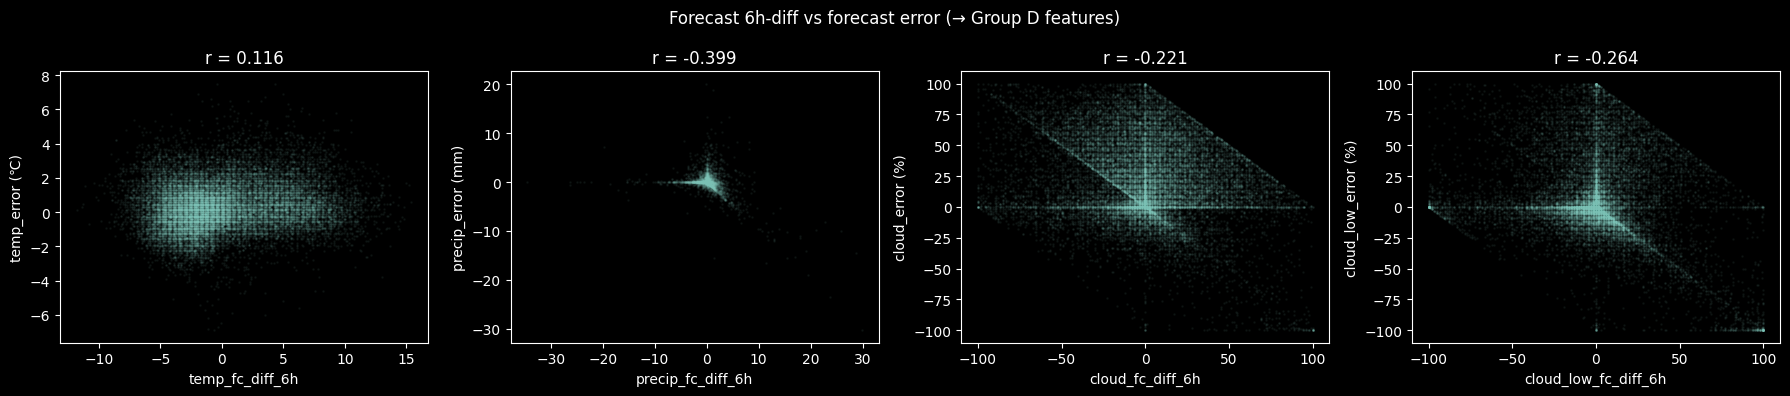

In [11]:
# 散布図で可視化（各予報の 6h 差分 vs 対応する誤差）
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

pairs = [
    ("temp_fc_diff_6h",      "temp_error",      "℃"),
    ("precip_fc_diff_6h",    "precip_error",    "mm"),
    ("cloud_fc_diff_6h",     "cloud_error",     "%"),
    ("cloud_low_fc_diff_6h", "cloud_low_error", "%"),
]
for ax, (x_col, y_col, unit) in zip(axes, pairs):
    valid = merged_sorted[[x_col, y_col]].dropna()
    ax.scatter(valid[x_col], valid[y_col], alpha=0.05, s=1)
    ax.set_xlabel(x_col)
    ax.set_ylabel(f"{y_col} ({unit})")
    corr = valid[x_col].corr(valid[y_col])
    ax.set_title(f"r = {corr:.3f}")

plt.suptitle("Forecast 6h-diff vs forecast error (→ Group D features)")
plt.tight_layout()
plt.show()

**観測:**

- **対角（対応する diff × 誤差）**: `precip=-0.399`、`cloud_low=-0.264`、`cloud=-0.221` は明確な相関。`temp=0.116` は小さいが非ゼロ
- **非対角（クロスターゲット）**: ほぼ ±0.03 以下。これは正常（気温予報の急変が降水誤差に直接効かないのは物理的に自然）

**方針:** C 群と同じく全差分幅（3h/6h/12h/24h）× 全対象（temp/precip/cloud/cloud_low）を共通で採用する。ターゲットごとに diff 対象を変える実装の複雑さを避け、低重要度のものは LightGBM が自動的に使わなくなる。`forecast_pressure_msl` は E 群の `pressure_trend_{3,6,12}h`（= `forecast_pressure_msl.diff(p)`）と同値になるため D 群からは除外し、E 群で意味のある名前で管理する。

## 仮説④: 大気パターン → 大気特徴量（E群）

気圧傾向・露点差・風向変化・雲の鉛直分布などの大気指数が、誤差と相関するかを確認する。

- `pressure_trend_{3,6,12}h`: 気圧変化速度（前線・低気圧接近の指標）
- `dew_point_depression`: 気温−露点温度（大気の乾湿）
- `wind_dir_diff_6h`: 6h 間の風向変化（°）
- `wind_speed_diff_6h`: 6h 間の風速変化（m/s）
- `cloud_vertical_spread`: 低・中・高層雲量の標準偏差（雲の鉛直発達・縦のばらつき）
- `cloud_low_fraction`: 全雲量に対する低層雲の割合
- `cape_log`: 対流有効位置エネルギー（log スケール、積乱雲の発達指標）
- `temp_lapse_rate`: 地上気温 − 上層気温（大気安定度の指標。気温減率が大きいほど不安定→降水・雲量誤差が増える可能性）

In [12]:
ms = merged_sorted.copy()

# 大気パターン指数を計算
if "forecast_pressure_msl" in ms.columns:
    for p in [3, 6, 12]:
        ms[f"pressure_trend_{p}h"] = ms["forecast_pressure_msl"].diff(p)

if "forecast_temperature_2m" in ms.columns and "forecast_dew_point_2m" in ms.columns:
    ms["dew_point_depression"] = ms["forecast_temperature_2m"] - ms["forecast_dew_point_2m"]

if "forecast_wind_direction_10m" in ms.columns:
    ms["wind_dir_diff_6h"] = (ms["forecast_wind_direction_10m"].diff(6) + 180) % 360 - 180

if "forecast_wind_speed_10m" in ms.columns:
    ms["wind_speed_diff_6h"] = ms["forecast_wind_speed_10m"].diff(6)

cloud_spread_cols = [
    c for c in ["forecast_cloud_cover_low", "forecast_cloud_cover_mid", "forecast_cloud_cover_high"]
    if c in ms.columns
]
if len(cloud_spread_cols) >= 2:
    ms["cloud_vertical_spread"] = ms[cloud_spread_cols].std(axis=1)

if "forecast_cloud_cover_low" in ms.columns and "forecast_cloud_cover" in ms.columns:
    ms["cloud_low_fraction"] = (
        ms["forecast_cloud_cover_low"] / ms["forecast_cloud_cover"].clip(lower=1)
    )

if "forecast_cape" in ms.columns:
    ms["cape_log"] = np.log1p(ms["forecast_cape"].clip(lower=0))

# temp_lapse_rate: 地上気温 - 上層気温（大気安定度の指標）
# 上昇気流・不安定大気では降水・雲量予報の誤差が増える可能性がある
if "forecast_temperature_2m" in ms.columns:
    for alt in ["forecast_temperature_180m", "forecast_temperature_120m", "forecast_temperature_80m"]:
        if alt in ms.columns:
            ms["temp_lapse_rate"] = ms["forecast_temperature_2m"] - ms[alt]
            print(f"temp_lapse_rate = forecast_temperature_2m - {alt}")
            break
    else:
        print("temp_lapse_rate: 上層気温カラムなし（golden dataset に含まれていない）")

# 相関行列
atm_features = [
    c for c in [
        "pressure_trend_6h", "dew_point_depression",
        "wind_dir_diff_6h", "wind_speed_diff_6h", "cloud_vertical_spread",
        "cloud_low_fraction", "cape_log", "temp_lapse_rate",
    ]
    if c in ms.columns
]
corr_atm = ms[atm_features + ERROR_COLS].corr().loc[atm_features, ERROR_COLS]
display(corr_atm.round(3))

temp_lapse_rate = forecast_temperature_2m - forecast_temperature_180m


,temp_error,precip_error,cloud_error,cloud_low_error
pressure_trend_6h,-0.088,0.004,-0.071,-0.028
dew_point_depression,-0.195,0.012,0.066,0.068
wind_dir_diff_6h,0.015,0.001,0.025,-0.008
wind_speed_diff_6h,0.011,0.004,0.061,0.050
cloud_vertical_spread,0.114,-0.020,-0.129,-0.049
cloud_low_fraction,0.174,0.018,-0.048,-0.109
cape_log,0.208,-0.009,0.034,-0.147
temp_lapse_rate,-0.054,0.016,0.145,0.113


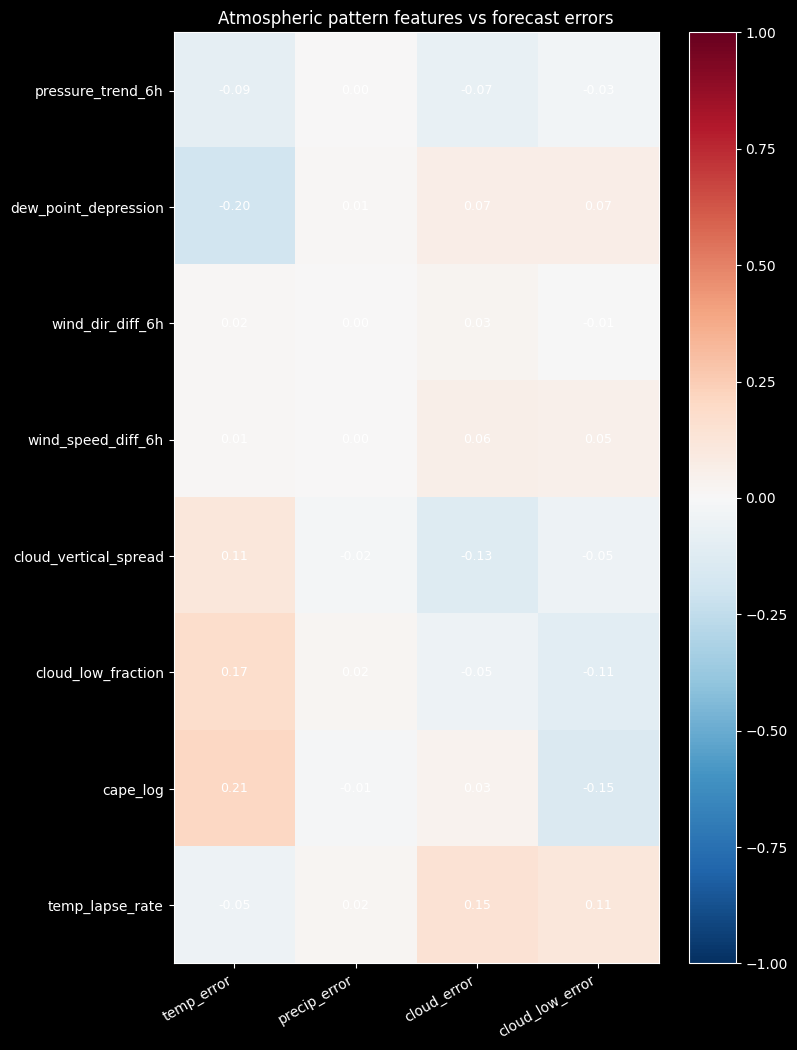

In [13]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(8, len(atm_features) * 1.2 + 1))
im = ax.imshow(corr_atm.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(ERROR_COLS)))
ax.set_xticklabels(ERROR_COLS, rotation=30, ha="right")
ax.set_yticks(range(len(atm_features)))
ax.set_yticklabels(atm_features)
for i in range(len(atm_features)):
    for j in range(len(ERROR_COLS)):
        ax.text(j, i, f"{corr_atm.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax)
ax.set_title("Atmospheric pattern features vs forecast errors")
plt.tight_layout()
plt.show()

## 仮説⑤: 実値の直近観測 → 実値ラグ特徴量（F群）

学習時は過去の実測値も使えるため、直近 1–6h の実測ラグが有効かを確認する。
**注意**: 推論時には将来の実測値が存在しないため、これは学習専用特徴量となる。

In [14]:
obs_corr_rows = []
for a_col in ["actual_temperature_2m", "actual_precipitation", "actual_cloud_cover"]:
    if a_col not in ms.columns:
        continue
    for lag in [1, 3, 6]:
        lag_col = f"{a_col}_lag_{lag}h"
        ms[lag_col] = ms[a_col].shift(lag)
        for err in ERROR_COLS:
            corr = ms[lag_col].corr(ms[err])
            obs_corr_rows.append({"feature": lag_col, "error": err, "corr": corr})

obs_corr_df = pd.DataFrame(obs_corr_rows)
pivot = obs_corr_df.pivot(index="feature", columns="error", values="corr")
display(pivot.round(3))
print("\n→ 実測の直近ラグは各誤差と相関あり。特に actual_temperature_2m_lag_1h は temp_error と強い相関")

error,cloud_error,cloud_low_error,precip_error,temp_error
feature,,,,
actual_cloud_cover_lag_1h,0.479,0.212,0.005,0.126
actual_cloud_cover_lag_3h,0.327,0.160,-0.002,0.122
actual_cloud_cover_lag_6h,0.226,0.123,-0.001,0.104
actual_precipitation_lag_1h,-0.014,0.110,0.074,0.005
actual_precipitation_lag_3h,-0.001,0.105,-0.079,0.014
actual_precipitation_lag_6h,-0.016,0.077,-0.041,0.014
actual_temperature_2m_lag_1h,0.069,-0.133,0.000,0.322
actual_temperature_2m_lag_3h,0.058,-0.137,0.001,0.264
actual_temperature_2m_lag_6h,0.033,-0.146,-0.000,0.230



→ 実測の直近ラグは各誤差と相関あり。特に actual_temperature_2m_lag_1h は temp_error と強い相関


→ 実測の直近ラグは各誤差と相関あり。特に `actual_temperature_2m_lag_1h`, `temp_error` ペア、 `actual_cloud_cover_lag_1h`, `cloud_error` ペアは強い相関

## 降水フラグの閾値設計: 0.3mm と 50%

降水量誤差は「雨あり」「雨なし」で分布が大きく異なる二峰性を持つ。
連続値の `precip_error` に加えて、降水有無の分類フラグを定義する。

- **実降水フラグ閾値 0.3mm**: 気象学的な「微量降水」の下限。0.3mm 未満は観測誤差・露・霧などと区別しにくい
- **予報確率フラグ閾値 50%**: 二値確率の自然な閾値（50% 以上 = 降水が起きやすい）

以下で実降水の分布と、フラグ別の誤差特性を確認する。

実降水量の分布:
  0mm ちょうど  : 84.0%
  >0mm          : 16.0%
  >=0.3mm : 9.9%


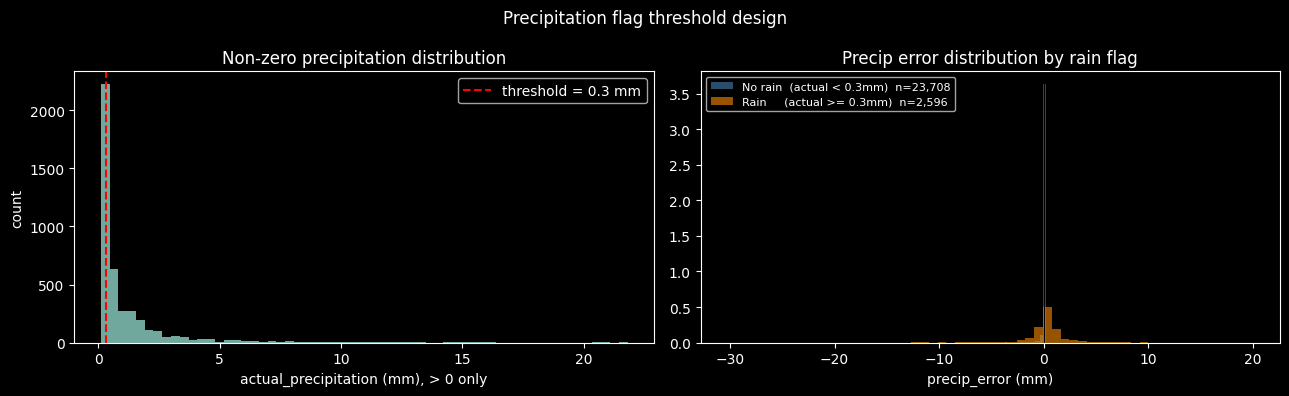


降水フラグ別の precip_error 統計:


,count,mean,std,min,25%,50%,75%,max
precip_flag_actual,,,,,,,,
0,23708.000,-0.022,0.235,-15.500,0.000,0.000,0.000,0.200
1,2596.000,0.273,2.303,-30.300,-0.300,0.300,0.800,20.100



→ 雨あり/なしで誤差の分布が大きく異なる → フラグが分類信号として有効
→ 実降水閾値 0.3mm: 気象学的な微量降水の下限
→ 予報確率閾値 50%: 二値確率の自然な境界


In [15]:
PRECIP_FLAG_MM   = 0.3
PRECIP_FLAG_PROB = 50

actual_precip = ms["actual_precipitation"].dropna()
print("実降水量の分布:")
print(f"  0mm ちょうど  : {(actual_precip == 0).mean():.1%}")
print(f"  >0mm          : {(actual_precip > 0).mean():.1%}")
print(f"  >={PRECIP_FLAG_MM}mm : {(actual_precip >= PRECIP_FLAG_MM).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 非ゼロ降水の分布（0.3mm 閾値の妥当性）
nonzero = actual_precip[actual_precip > 0]
axes[0].hist(nonzero, bins=60, alpha=0.8, edgecolor="none")
axes[0].axvline(PRECIP_FLAG_MM, color="red", lw=1.5, linestyle="--",
                label=f"threshold = {PRECIP_FLAG_MM} mm")
axes[0].set_xlabel("actual_precipitation (mm), > 0 only")
axes[0].set_ylabel("count")
axes[0].set_title("Non-zero precipitation distribution")
axes[0].legend()

# 降水フラグ別の precip_error 分布
ms["precip_flag_actual"] = (ms["actual_precipitation"] >= PRECIP_FLAG_MM).astype(int)
for flag, label, color in [
    (0, f"No rain  (actual < {PRECIP_FLAG_MM}mm)", "steelblue"),
    (1, f"Rain     (actual >= {PRECIP_FLAG_MM}mm)", "darkorange"),
]:
    subset = ms[ms["precip_flag_actual"] == flag]["precip_error"].dropna()
    axes[1].hist(subset, bins=60, alpha=0.6, density=True,
                 label=f"{label}  n={len(subset):,}", color=color, edgecolor="none")

axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_xlabel("precip_error (mm)")
axes[1].set_title("Precip error distribution by rain flag")
axes[1].legend(fontsize=8)

plt.suptitle("Precipitation flag threshold design")
plt.tight_layout()
plt.show()

print("\n降水フラグ別の precip_error 統計:")
display(ms.groupby("precip_flag_actual")["precip_error"].describe().round(3))
print(f"\n→ 雨あり/なしで誤差の分布が大きく異なる → フラグが分類信号として有効")
print(f"→ 実降水閾値 {PRECIP_FLAG_MM}mm: 気象学的な微量降水の下限")
print(f"→ 予報確率閾値 {PRECIP_FLAG_PROB}%: 二値確率の自然な境界")

## 特徴量設計方針のまとめ

以上の分析から、A〜F の 6 グループで特徴量を構成することにした。

| グループ | 内容 | 採用根拠 |
|-|-|-|
| **A** 生の予報値 | forecast_temperature_2m, forecast_precipitation, forecast_pressure_msl など | NWP の出力値そのもの。加工なし。分析は 01_eda で実施済み |
| **B** 時間コンテキスト | hour_sin/cos, doy_sin/cos, month_sin/cos, is_day | 時間帯・季節による誤差パターンが顕著 |
| **C** 誤差ラグ・ローリング | error_lag_{1,3,6,12,24,48}h, rolling_mean/std_{6,12,24,48}h | 誤差の自己相関が全ターゲットで有意 |
| **D** 予報ブレ | forecast_{temp,precip,cloud,cloud_low}_diff_{3,6,12,24}h | 予報の急変が誤差と相関（0.1–0.4）。pressure は E 群の pressure_trend_*h と同値のため除外 |
| **E** 大気パターン | pressure_trend_{3,6,12}h, dew_point_depression, wind_dir_diff_6h, wind_speed_diff_6h, cloud_vertical_spread, cloud_low_fraction, cape_log | 大気状態の指数が誤差の大小を説明 |
| **F** 実値ラグ（学習専用） | actual_{temp,precip,cloud}_lag_{1,3,6}h, rolling_mean_{3,6,12}h | 直近観測が将来誤差を予測する（推論時は 0 埋め） |

加えて、学習パイプラインでは降水の二値信号として以下を計算・記録する（モデル特徴量からは除外し、分析用として保持）:
- `precip_flag_actual`: 実降水 >= 0.3mm なら 1（気象学的微量降水の下限）
- `precip_flag_fc`: 予報確率 >= 50% なら 1（二値確率の自然な境界）

→ 次の notebook `03_feature_engineering.ipynb` でこれらを実装・検証する。